<a href="https://colab.research.google.com/github/M-EL-YAMANI/M-EL-YAMANI/blob/main/05_LSTM_Corrige.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌊 Prédiction de l'apport entrant au barrage — LSTM corrigé## Code structuré, configuration centralisée, division 4:1 (64/16/20)**Corrections apportées par rapport à la version précédente** (qui sous-estimait le débit de ~50%, PBIAS ≈ -50%) :- **Régularisation réduite** : `dropout` 0.3→0.1, `l2_reg` supprimé. La distribution des débits est très asymétrique (skew≈7, beaucoup de zéros et quelques pics >1000 m³/s) ; trop de régularisation tire les prédictions vers la moyenne et écrase les crues.- **Loss = MSE** (au lieu de Huber) : pénalise quadratiquement les grosses erreurs et force le modèle à apprendre les pics de crue plutôt que de les traiter comme des outliers.- **Architecture simplifiée** : 1 couche Bi-LSTM (64 unités), **sans attention** par défaut — une baseline saine avant d'ajouter de la complexité.- **Entraînement plus long** (`epochs`=300, `es_patience`=40) pour laisser le modèle converger sur les événements rares.- **Correction de biais post-hoc optionnelle** : facteur multiplicatif calibré sur le train pour corriger un biais résiduel.Code organisé en fonctions réutilisables, avec une configuration centralisée (`CONFIG`).

## 1. Configuration & imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings, time
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import tensorflow as tf
from tensorflow.keras.layers import (Input, Dense, LSTM, Bidirectional, Dropout,
                                      MultiHeadAttention, LayerNormalization,
                                      GlobalAveragePooling1D, Add)
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ----------------------------------------------------------------
# CONFIGURATION CENTRALISÉE — modifier ici pour ajuster le pipeline
# ----------------------------------------------------------------
CONFIG = {
    'data_path'        : 'dataset_1979_2007.csv',
    'date_col'         : 'Date',
    'target_col'       : 'Barrage',
    'station_cols'     : ["M'Douar", 'Oughane', "M'ghar", 'Bouffarah'],

    'window_size'      : 14,        # taille de la fenêtre temporelle (jours)
    'split_ratio'      : 0.20,      # proportion test (4:1 -> 1/5)
    'val_ratio'        : 0.20,      # proportion validation au sein du train (4:1 -> 1/5)

    'units'            : 64,        # unités LSTM (réduit : 128 -> 64, trop de capacité = sur-lissage)
    'n_layers'         : 1,         # 1 couche (réduit : 2 -> 1, baseline saine)
    'bidirectional'    : True,
    'dropout'          : 0.1,       # réduit : 0.3 -> 0.1 (trop de dropout écrase les pics)
    'l2_reg'           : 0.0,       # supprimé : 1e-5 -> 0 (régularisation excessive = biais négatif)
    'use_attention'    : False,     # désactivé par défaut (baseline avant complexification)
    'attention_heads'  : 4,

    'loss'             : 'mse',     # MSE (au lieu de Huber) : pénalise fortement les pics de crue
    'learning_rate'    : 1e-3,
    'batch_size'       : 64,
    'epochs'           : 300,       # augmenté : 200 -> 300 (laisser converger sur les événements rares)
    'es_patience'      : 40,        # augmenté : 25 -> 40
    'lr_patience'      : 15,

    'apply_bias_correction': True,  # correction multiplicative post-hoc calibrée sur le train
}

print(f"TensorFlow {tf.__version__} | GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")
print("Configuration chargée.")

TensorFlow 2.20.0 | GPU: False
Configuration chargée.


## 2. Chargement des données

In [2]:
def load_data(cfg):
    df = pd.read_csv(cfg['data_path'])
    df[cfg['date_col']] = pd.to_datetime(df[cfg['date_col']])
    df = df.sort_values(cfg['date_col']).reset_index(drop=True)
    return df

df = load_data(CONFIG)
print(f"Période : {df[CONFIG['date_col']].min().date()} -> {df[CONFIG['date_col']].max().date()}")
print(f"Lignes  : {len(df):,}")
df.describe().round(3)

Période : 1979-09-01 -> 2007-08-31
Lignes  : 10,227


,Date,Barrage,M'Douar,Oughane,M'ghar,Bouffarah
count,10227,10227.000,10227.000,10227.000,10227.000,10227.000
mean,1993-08-31 00:00:00,18.067,10.416,2.500,0.885,3.683
min,1979-09-01 00:00:00,0.000,0.000,0.000,0.000,0.000
25%,1986-08-31 12:00:00,0.000,0.154,0.012,0.014,0.060
50%,1993-08-31 00:00:00,1.769,0.912,0.181,0.072,0.398
75%,2000-08-30 12:00:00,9.988,5.306,1.187,0.367,2.046
max,2007-08-31 00:00:00,1487.199,1029.627,252.659,58.377,262.627
std,NaN,67.045,37.984,10.246,3.252,12.227


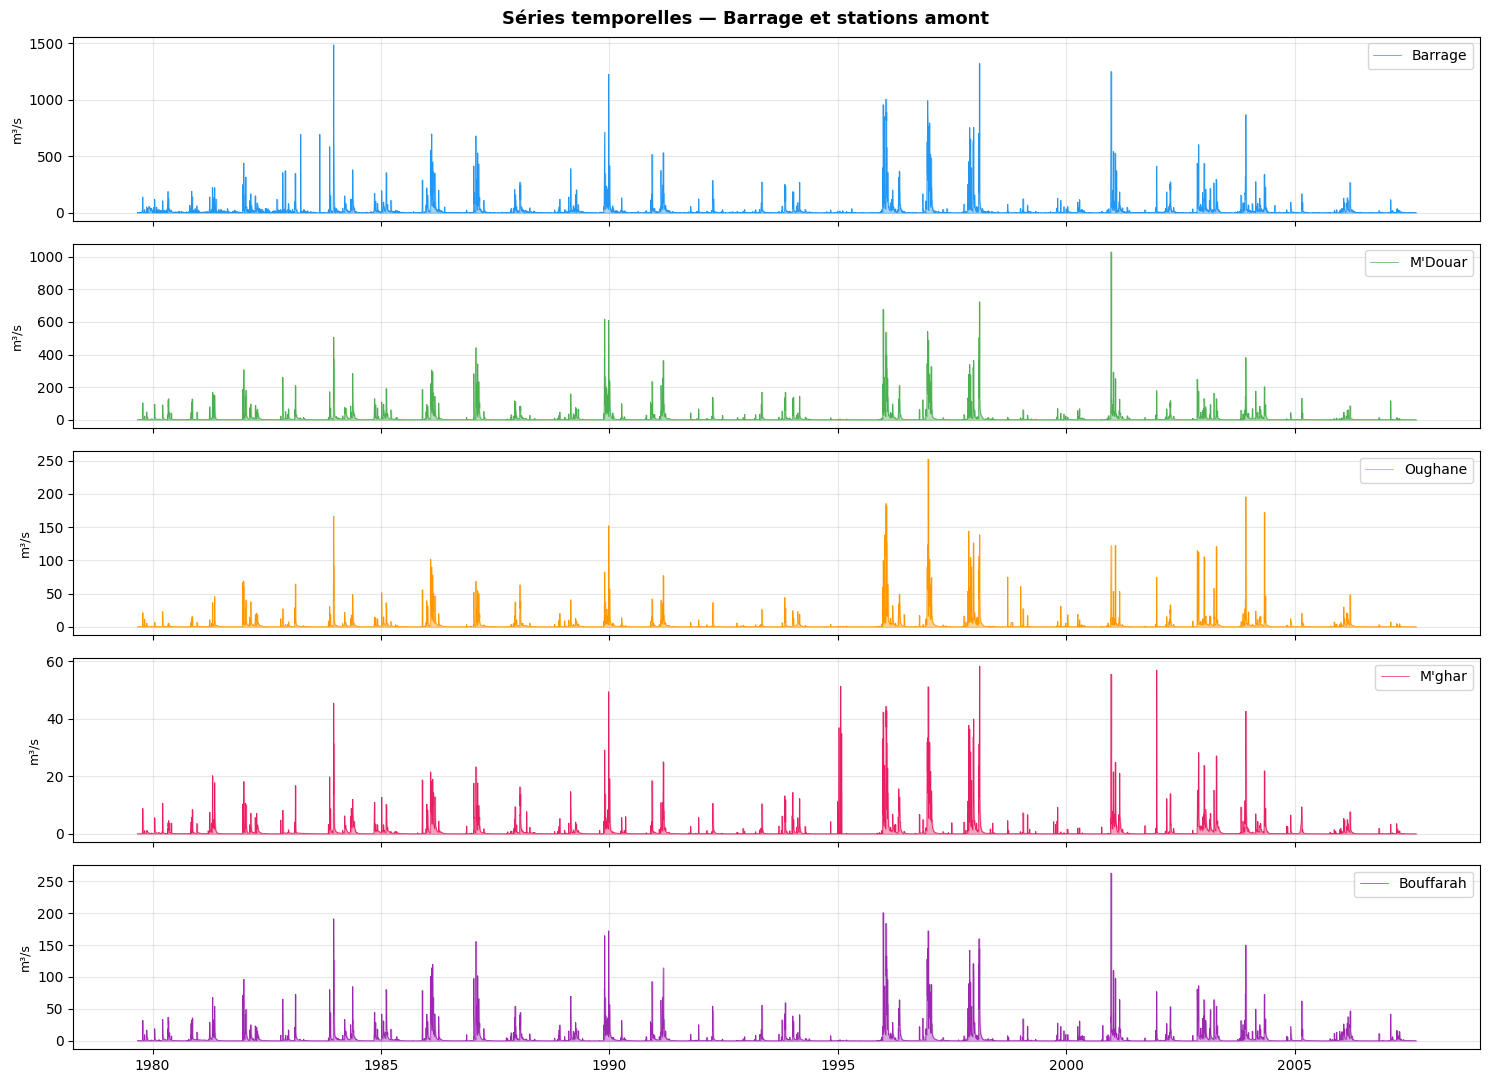

In [3]:
fig, axes = plt.subplots(5, 1, figsize=(15, 11), sharex=True)
cols   = [CONFIG['target_col']] + CONFIG['station_cols']
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
for ax, col, c in zip(axes, cols, colors):
    ax.fill_between(df[CONFIG['date_col']], df[col], alpha=0.4, color=c)
    ax.plot(df[CONFIG['date_col']], df[col], color=c, linewidth=0.5, label=col)
    ax.set_ylabel('m³/s', fontsize=9); ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[-1].xaxis.set_major_locator(mdates.YearLocator(5))
fig.suptitle('Séries temporelles — Barrage et stations amont', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('01_series_temporelles.png', dpi=150, bbox_inches='tight'); plt.show()

## 3. Ingénierie des features- **log1p** sur les débits amont (réduit l'asymétrie)- **somme** + **moyennes glissantes 3j/7j** des stations amont (mémoire hydrologique)- **encodage cyclique** mois / jour de l'année (saisonnalité)

In [4]:
def engineer_features(df, cfg):
    out = df.copy()

    log_station_cols = []
    for c in cfg['station_cols']:
        new_c = c + '_log'
        out[new_c] = np.log1p(out[c])
        log_station_cols.append(new_c)

    out['sum_log']   = out[log_station_cols].sum(axis=1)
    out['roll3_log'] = out['sum_log'].rolling(window=3, min_periods=1).mean()
    out['roll7_log'] = out['sum_log'].rolling(window=7, min_periods=1).mean()

    out['month']     = out[cfg['date_col']].dt.month
    out['dayofyear'] = out[cfg['date_col']].dt.dayofyear
    out['month_sin'] = np.sin(2*np.pi*out['month']/12)
    out['month_cos'] = np.cos(2*np.pi*out['month']/12)
    out['doy_sin']   = np.sin(2*np.pi*out['dayofyear']/365)
    out['doy_cos']   = np.cos(2*np.pi*out['dayofyear']/365)

    feature_cols = log_station_cols + ['sum_log', 'roll3_log', 'roll7_log',
                                        'month_sin', 'month_cos', 'doy_sin', 'doy_cos']
    return out, feature_cols

df_feat, FEATURE_COLS = engineer_features(df, CONFIG)
print(f"Features ({len(FEATURE_COLS)}) :", FEATURE_COLS)

Features (11) : ["M'Douar_log", 'Oughane_log', "M'ghar_log", 'Bouffarah_log', 'sum_log', 'roll3_log', 'roll7_log', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos']


## 4. Division chronologique 4:1 (64% / 16% / 20%)

Train      : 1979-09-01 -> 1997-08-02  (6,546 j, 64.0%)
Validation : 1997-08-03 -> 2002-01-24  (1,636 j, 16.0%)
Test       : 2002-01-25 -> 2007-08-31  (2,045 j, 20.0%)


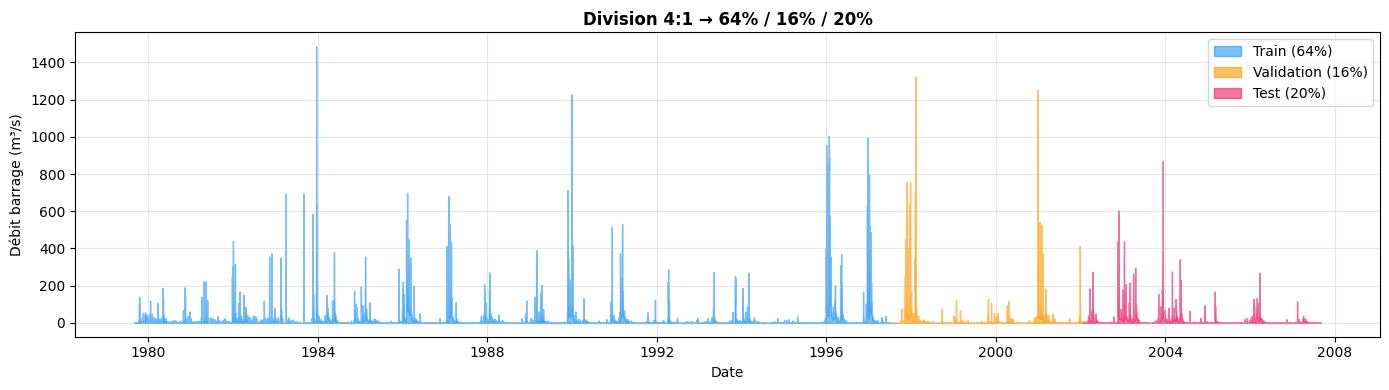

In [5]:
def split_data(df, cfg):
    n = len(df)
    test_size = int(n * cfg['split_ratio'])
    train_val_size = n - test_size
    val_size = int(train_val_size * cfg['val_ratio'])
    train_size = train_val_size - val_size

    train_df = df.iloc[:train_size].reset_index(drop=True)
    val_df   = df.iloc[train_size:train_size+val_size].reset_index(drop=True)
    test_df  = df.iloc[train_size+val_size:].reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = split_data(df_feat, CONFIG)
n = len(df_feat)
for name, d in [('Train', train_df), ('Validation', val_df), ('Test', test_df)]:
    print(f"{name:<11}: {d[CONFIG['date_col']].min().date()} -> {d[CONFIG['date_col']].max().date()}  "
          f"({len(d):,} j, {len(d)/n:.1%})")

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(train_df[CONFIG['date_col']], train_df[CONFIG['target_col']], alpha=0.6, color='#2196F3', label='Train (64%)')
ax.fill_between(val_df[CONFIG['date_col']],   val_df[CONFIG['target_col']],   alpha=0.6, color='#FF9800', label='Validation (16%)')
ax.fill_between(test_df[CONFIG['date_col']],  test_df[CONFIG['target_col']],  alpha=0.6, color='#E91E63', label='Test (20%)')
ax.set_xlabel('Date'); ax.set_ylabel('Débit barrage (m³/s)')
ax.set_title('Division 4:1 → 64% / 16% / 20%', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('02_division_donnees.png', dpi=150, bbox_inches='tight'); plt.show()

## 5. Normalisation

In [6]:
def fit_scalers(train_df, cfg):
    scaler_X = MinMaxScaler().fit(train_df[FEATURE_COLS].values)
    y_log = np.log1p(train_df[cfg['target_col']].values).reshape(-1, 1)
    scaler_y = StandardScaler().fit(y_log)
    scaler_flow = StandardScaler().fit(y_log)
    return scaler_X, scaler_y, scaler_flow

def transform_split(d, cfg, scaler_X, scaler_y, scaler_flow):
    X = scaler_X.transform(d[FEATURE_COLS].values)
    y_log = np.log1p(d[cfg['target_col']].values).reshape(-1, 1)
    y = scaler_y.transform(y_log)
    flow = scaler_flow.transform(y_log)
    return X, y, flow

scaler_X, scaler_y, scaler_flow = fit_scalers(train_df, CONFIG)

X_train, y_train, flow_train = transform_split(train_df, CONFIG, scaler_X, scaler_y, scaler_flow)
X_val,   y_val,   flow_val   = transform_split(val_df,   CONFIG, scaler_X, scaler_y, scaler_flow)
X_test,  y_test,  flow_test  = transform_split(test_df,  CONFIG, scaler_X, scaler_y, scaler_flow)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)

X_train: (6546, 11) | y_train: (6546, 1)


## 6. Fenêtres glissantes

In [7]:
def make_sequences(X_feat, y_scaled, flow_scaled, window):
    """Construit les séquences (features amont + débit barrage passé) -> cible au jour J."""
    X_seq, y_out = [], []
    for i in range(window, len(X_feat)):
        past_feat = X_feat[i-window:i]
        past_flow = flow_scaled[i-window:i].reshape(-1, 1)
        X_seq.append(np.hstack([past_feat, past_flow]))
        y_out.append(y_scaled[i])
    return np.array(X_seq), np.array(y_out)

W = CONFIG['window_size']
X_train_seq, y_tr = make_sequences(X_train, y_train, flow_train, W)
X_val_seq,   y_vl = make_sequences(X_val,   y_val,   flow_val,   W)
X_test_seq,  y_ts = make_sequences(X_test,  y_test,  flow_test,  W)

dates_test = test_df[CONFIG['date_col']].values[W:]
N_FEATURES = X_train_seq.shape[2]

print(f"Fenêtre = {W} jours | N_FEATURES = {N_FEATURES}")
print("Shapes:", X_train_seq.shape, X_val_seq.shape, X_test_seq.shape)

Fenêtre = 14 jours | N_FEATURES = 12
Shapes: (6532, 14, 12) (1622, 14, 12) (2031, 14, 12)


## 7. Architecture du modèle : LSTM empilé bidirectionnel + Attention

In [8]:
def build_model(timesteps, n_features, cfg):
    reg = tf.keras.regularizers.l2(cfg['l2_reg'])
    inputs = Input(shape=(timesteps, n_features), name='input')
    x = inputs

    for i in range(cfg['n_layers']):
        return_seq = (i < cfg['n_layers'] - 1) or cfg['use_attention']
        lstm = LSTM(cfg['units'], return_sequences=return_seq, dropout=cfg['dropout'],
                    kernel_regularizer=reg, recurrent_regularizer=reg,
                    name=f'lstm_{i+1}')
        x = Bidirectional(lstm, name=f'bi_{i+1}')(x) if cfg['bidirectional'] else lstm(x)

    if cfg['use_attention']:
        dim = cfg['units'] * (2 if cfg['bidirectional'] else 1)
        attn = MultiHeadAttention(num_heads=cfg['attention_heads'],
                                   key_dim=max(dim // cfg['attention_heads'], 8),
                                   name='attention')(x, x)
        x = Add(name='residual')([x, attn])
        x = LayerNormalization(name='layer_norm')(x)
        x = GlobalAveragePooling1D(name='global_avg_pool')(x)

    x = Dense(32, activation='relu', kernel_regularizer=reg, name='dense_hidden')(x)
    x = Dropout(cfg['dropout'], name='dropout_out')(x)
    output = Dense(1, name='output')(x)

    return Model(inputs, output, name='LSTM_Attention_Model')

model = build_model(W, N_FEATURES, CONFIG)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=CONFIG['learning_rate']),
    loss=CONFIG['loss'],   # 'mse' : pénalise fortement les pics de crue (vs Huber qui les sous-pondère)
    metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')]
)
model.summary()

Model: "LSTM_Attention_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 14, 12)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bi_1 (Bidirectional)            │ (None, 128)            │        39,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_out (Dropout)           │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,585 (170.25 KB)

 Trainable params: 43,585 (170.25 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Entraînement

In [9]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=CONFIG['es_patience'], restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=CONFIG['lr_patience'], min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, verbose=0)
]

t0 = time.time()
history = model.fit(
    X_train_seq, y_tr,
    validation_data=(X_val_seq, y_vl),
    epochs=CONFIG['epochs'],
    batch_size=CONFIG['batch_size'],
    callbacks=callbacks,
    verbose=1
)
train_time = time.time() - t0
print(f"\nTerminé en {len(history.history['loss'])} epochs ({train_time:.1f}s)")

Epoch 1/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 0.4039 - rmse: 0.6355 - val_loss: 0.2549 - val_rmse: 0.5049 - learning_rate: 0.0010
Epoch 2/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3463 - rmse: 0.5885 - val_loss: 0.2399 - val_rmse: 0.4898 - learning_rate: 0.0010
Epoch 3/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.3364 - rmse: 0.5800 - val_loss: 0.2357 - val_rmse: 0.4855 - learning_rate: 0.0010
Epoch 4/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.3327 - rmse: 0.5768 - val_loss: 0.2331 - val_rmse: 0.4828 - learning_rate: 0.0010
Epoch 5/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.3247 - rmse: 0.5698 - val_loss: 0.2314 - val_rmse: 0.4810 - learning_rate: 0.0010
Epoch 6/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.3176 - rmse: 0.5636 - val_loss: 0.2327 - val_rmse: 0.4824 - learning_rate: 0.0010
Epoch 7/300
103/103 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.3181 - rmse: 0.5640 - val_loss: 0.2307 - val_rmse: 0.4803 - 

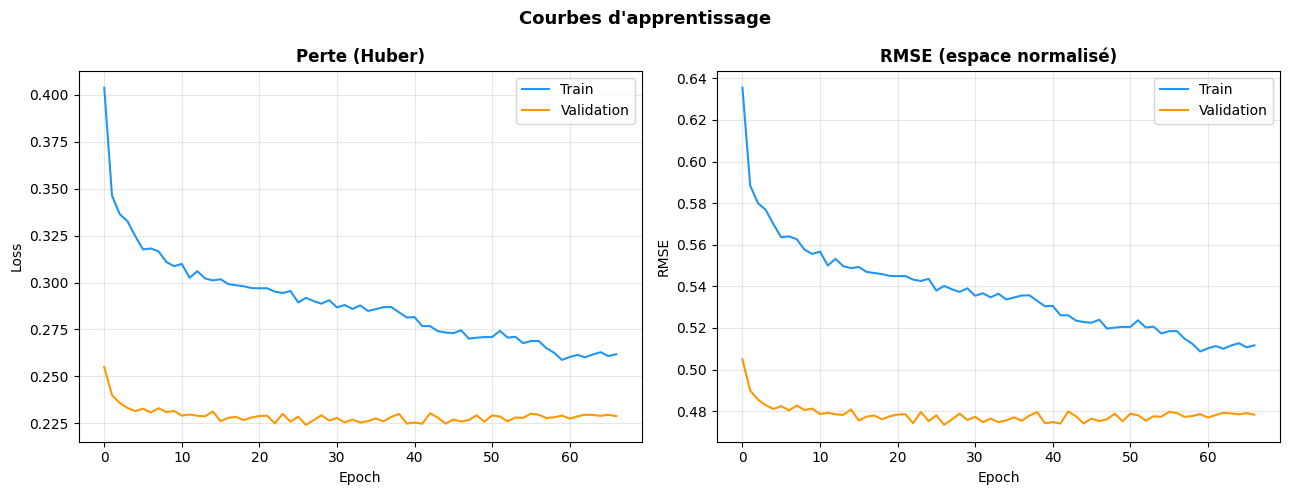

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(history.history['loss'],     label='Train', color='#2196F3')
axes[0].plot(history.history['val_loss'], label='Validation', color='#FF9800')
axes[0].set_title('Perte (Huber)', fontweight='bold'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['rmse'],     label='Train', color='#2196F3')
axes[1].plot(history.history['val_rmse'], label='Validation', color='#FF9800')
axes[1].set_title('RMSE (espace normalisé)', fontweight='bold'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('RMSE')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle("Courbes d'apprentissage", fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('03_courbes_apprentissage.png', dpi=150, bbox_inches='tight'); plt.show()

## 9. Métriques d'évaluation

In [11]:
def predict_and_inverse(model, X, y_scaled, scaler_y):
    y_pred_sc = model.predict(X, verbose=0).reshape(-1, 1)
    y_pred = np.clip(np.expm1(scaler_y.inverse_transform(y_pred_sc).flatten()), 0, None)
    y_true = np.expm1(scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).flatten())
    return y_pred, y_true

def compute_metrics(y_obs, y_sim):
    rmse  = np.sqrt(mean_squared_error(y_obs, y_sim))
    mae   = mean_absolute_error(y_obs, y_sim)
    r2    = r2_score(y_obs, y_sim)
    nse   = 1 - np.sum((y_sim-y_obs)**2) / np.sum((y_obs-np.mean(y_obs))**2)
    r     = np.corrcoef(y_sim, y_obs)[0, 1]
    alpha = np.std(y_sim) / np.std(y_obs)
    beta  = np.mean(y_sim) / np.mean(y_obs)
    kge   = 1 - np.sqrt((r-1)**2 + (alpha-1)**2 + (beta-1)**2)
    pbias = 100 * np.sum(y_sim - y_obs) / np.sum(y_obs)
    log_obs, log_sim = np.log1p(y_obs), np.log1p(np.clip(y_sim, 0, None))
    log_nse = 1 - np.sum((log_sim-log_obs)**2) / np.sum((log_obs-np.mean(log_obs))**2)
    return {'RMSE': rmse, 'MAE': mae, 'R2': r2, 'NSE': nse, 'log_NSE': log_nse,
            'KGE': kge, 'PBIAS_%': pbias}

pred_train, true_train = predict_and_inverse(model, X_train_seq, y_tr, scaler_y)
pred_val,   true_val   = predict_and_inverse(model, X_val_seq,   y_vl, scaler_y)
pred_test,  true_test  = predict_and_inverse(model, X_test_seq,  y_ts, scaler_y)

eval_raw_df = pd.DataFrame({
    'Train':      compute_metrics(true_train, pred_train),
    'Validation': compute_metrics(true_val,   pred_val),
    'Test':       compute_metrics(true_test,  pred_test),
}).T.round(4)

print("="*60)
print("  PERFORMANCE BRUTE (sans correction de biais)")
print("="*60)
print(eval_raw_df.to_string())
print("="*60)
eval_raw_df

  PERFORMANCE BRUTE (sans correction de biais)
               RMSE      MAE      R2     NSE  log_NSE     KGE  PBIAS_%
Train       54.5875  11.3270  0.3845  0.3845   0.7263  0.1959 -44.6232
Validation  66.2552  11.8032  0.2968  0.2968   0.7621  0.1299 -45.5907
Test        34.9216   7.9195  0.4072  0.4072   0.8186  0.2719 -37.4458


,RMSE,MAE,R2,NSE,log_NSE,KGE,PBIAS_%
Train,54.5875,11.3270,0.3845,0.3845,0.7263,0.1959,-44.6232
Validation,66.2552,11.8032,0.2968,0.2968,0.7621,0.1299,-45.5907
Test,34.9216,7.9195,0.4072,0.4072,0.8186,0.2719,-37.4458


## 9bis. Correction de biais post-hocSi un biais systématique subsiste (PBIAS significatif), on applique un **facteur multiplicatif** calibré sur le train : `facteur = mean(observé_train) / mean(prédit_train)`. Ce facteur est ensuite appliqué à toutes les prédictions (train/val/test).

In [12]:
if CONFIG['apply_bias_correction']:
    bias_factor = np.mean(true_train) / np.mean(pred_train)
    print(f"Facteur de correction de biais (calibré sur train) : {bias_factor:.4f}")

    pred_train_c = pred_train * bias_factor
    pred_val_c   = pred_val   * bias_factor
    pred_test_c  = pred_test  * bias_factor

    eval_df = pd.DataFrame({
        'Train':      compute_metrics(true_train, pred_train_c),
        'Validation': compute_metrics(true_val,   pred_val_c),
        'Test':       compute_metrics(true_test,  pred_test_c),
    }).T.round(4)

    print("\n" + "="*60)
    print("  PERFORMANCE APRÈS CORRECTION DE BIAIS")
    print("="*60)
    print(eval_df.to_string())
    print("="*60)

    # Remplace les prédictions utilisées dans la suite du notebook
    pred_train, pred_val, pred_test = pred_train_c, pred_val_c, pred_test_c
else:
    bias_factor = 1.0
    eval_df = eval_raw_df

eval_df

Facteur de correction de biais (calibré sur train) : 1.8058

  PERFORMANCE APRÈS CORRECTION DE BIAIS
               RMSE      MAE      R2     NSE  log_NSE     KGE  PBIAS_%
Train       49.9895  13.3707  0.4838  0.4838   0.6673  0.5934  -0.0000
Validation  63.8079  14.7213  0.3478  0.3478   0.7023  0.4867  -1.7472
Test        33.4502  10.1060  0.4561  0.4561   0.7664  0.6221  12.9610


,RMSE,MAE,R2,NSE,log_NSE,KGE,PBIAS_%
Train,49.9895,13.3707,0.4838,0.4838,0.6673,0.5934,-0.0000
Validation,63.8079,14.7213,0.3478,0.3478,0.7023,0.4867,-1.7472
Test,33.4502,10.1060,0.4561,0.4561,0.7664,0.6221,12.9610


## 10. Visualisation des résultats

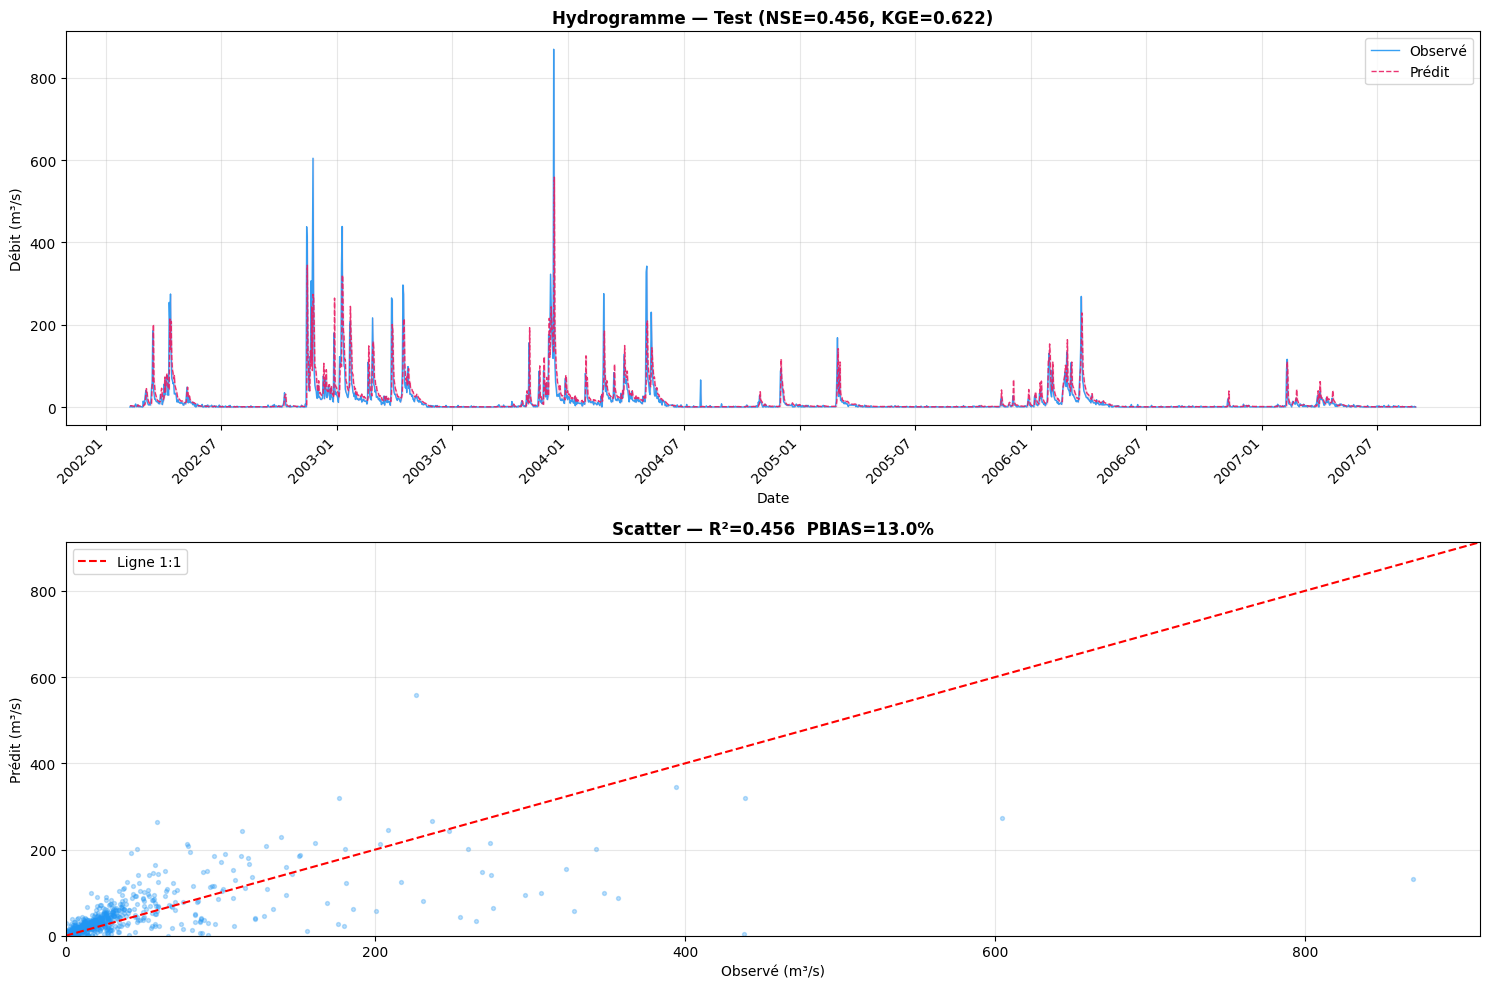

In [13]:
dates_test_pd = pd.to_datetime(dates_test)
m_test = compute_metrics(true_test, pred_test)  # pred_test = corrigé si apply_bias_correction=True

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

ax = axes[0]
ax.plot(dates_test_pd, true_test, color='#2196F3', linewidth=1.0, label='Observé', alpha=0.9)
ax.plot(dates_test_pd, pred_test, color='#E91E63', linewidth=1.0, label='Prédit',  alpha=0.9, linestyle='--')
ax.fill_between(dates_test_pd, true_test, pred_test, alpha=0.15, color='#E91E63')
ax.set_xlabel('Date'); ax.set_ylabel('Débit (m³/s)')
ax.set_title(f"Hydrogramme — Test (NSE={m_test['NSE']:.3f}, KGE={m_test['KGE']:.3f})", fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')

ax2 = axes[1]
max_val = max(true_test.max(), pred_test.max()) * 1.05
ax2.scatter(true_test, pred_test, alpha=0.3, s=8, color='#2196F3')
ax2.plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Ligne 1:1')
ax2.set_xlabel('Observé (m³/s)'); ax2.set_ylabel('Prédit (m³/s)')
ax2.set_title(f"Scatter — R²={m_test['R2']:.3f}  PBIAS={m_test['PBIAS_%']:.1f}%", fontweight='bold')
ax2.legend(); ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_val); ax2.set_ylim(0, max_val)

plt.tight_layout(); plt.savefig('04_resultats_test.png', dpi=150, bbox_inches='tight'); plt.show()

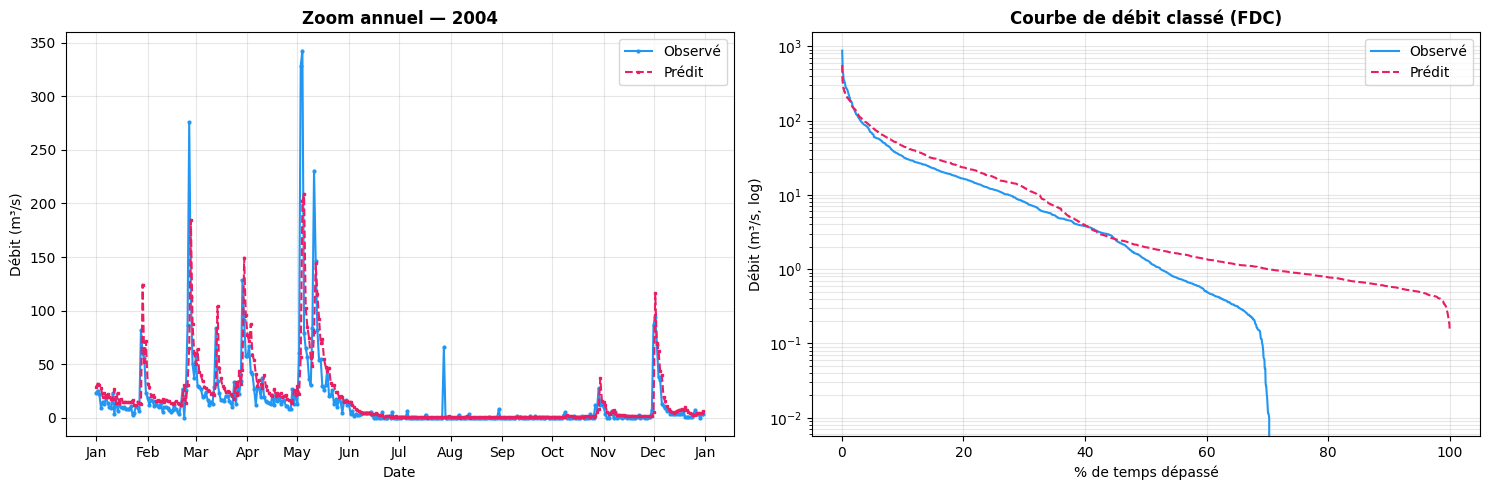

In [14]:
# Zoom annuel + courbe de débit classé (FDC)
zoom_year = dates_test_pd[len(dates_test_pd)//2].year
mask = dates_test_pd.year == zoom_year

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(dates_test_pd[mask], true_test[mask], color='#2196F3', linewidth=1.5, label='Observé', marker='o', markersize=2)
axes[0].plot(dates_test_pd[mask], pred_test[mask], color='#E91E63', linewidth=1.5, label='Prédit',  marker='s', markersize=2, linestyle='--')
axes[0].set_title(f'Zoom annuel — {zoom_year}', fontweight='bold')
axes[0].set_xlabel('Date'); axes[0].set_ylabel('Débit (m³/s)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator())

obs_sorted = np.sort(true_test)[::-1]
sim_sorted = np.sort(pred_test)[::-1]
exceedance = np.arange(1, len(obs_sorted)+1) / len(obs_sorted) * 100
axes[1].plot(exceedance, obs_sorted, label='Observé', color='#2196F3')
axes[1].plot(exceedance, sim_sorted, label='Prédit',  color='#E91E63', linestyle='--')
axes[1].set_yscale('log')
axes[1].set_xlabel('% de temps dépassé'); axes[1].set_ylabel('Débit (m³/s, log)')
axes[1].set_title('Courbe de débit classé (FDC)', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3, which='both')

plt.tight_layout(); plt.savefig('05_diagnostics.png', dpi=150, bbox_inches='tight'); plt.show()

## 11. Sauvegarde

In [15]:
model.save('lstm_corrige_final.keras')
eval_df.to_csv('metriques_finales.csv')
eval_raw_df.to_csv('metriques_brutes.csv')

results_df = pd.DataFrame({
    'Date': dates_test_pd, 'Observe': true_test, 'Predit': pred_test, 'Erreur': pred_test - true_test
})
results_df.to_csv('predictions_test.csv', index=False)

print("Fichiers sauvegardés :")
print("  - lstm_corrige_final.keras")
print("  - best_model.keras")
print("  - metriques_finales.csv (après correction de biais)")
print("  - metriques_brutes.csv (avant correction)")
print("  - predictions_test.csv")

print("\n" + "="*55)
print("  RÉSUMÉ")
print("="*55)
print(f"  Architecture : {'Bi-' if CONFIG['bidirectional'] else ''}LSTM {CONFIG['n_layers']}x{CONFIG['units']}"
      f"{' + Attention' if CONFIG['use_attention'] else ''}")
print(f"  Fenêtre      : {CONFIG['window_size']} jours")
print(f"  Loss         : {CONFIG['loss']}")
print(f"  Dropout      : {CONFIG['dropout']} | L2 : {CONFIG['l2_reg']}")
print(f"  Paramètres   : {model.count_params():,}")
print(f"  Bias factor  : {bias_factor:.4f}")
print()
print(f"  {'Métrique':<8} {'Avant corr.':>12} {'Après corr.':>12}")
for met in ['RMSE','NSE','log_NSE','KGE','PBIAS_%','R2']:
    print(f"  {met:<8} {eval_raw_df.loc['Test', met]:>12.4f} {eval_df.loc['Test', met]:>12.4f}")
print("="*55)

Fichiers sauvegardés :
  - lstm_corrige_final.keras
  - best_model.keras
  - metriques_finales.csv (après correction de biais)
  - metriques_brutes.csv (avant correction)
  - predictions_test.csv

  RÉSUMÉ
  Architecture : Bi-LSTM 1x64
  Fenêtre      : 14 jours
  Loss         : mse
  Dropout      : 0.1 | L2 : 0.0
  Paramètres   : 43,585
  Bias factor  : 1.8058

  Métrique  Avant corr.  Après corr.
  RMSE          34.9216      33.4502
  NSE            0.4072       0.4561
  log_NSE        0.8186       0.7664
  KGE            0.2719       0.6221
  PBIAS_%      -37.4458      12.9610
  R2             0.4072       0.4561
